<a href="https://colab.research.google.com/github/bhandarsachin/API/blob/main/Bank_churn_pridection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df[df['churn'].isnull()]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [ ]:
df[df['churn'].isnull()]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [ ]:
df.head(15)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
df['churn'].isnull()

,churn
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df[(df['country'] == 'Spain') & (df['gender'] == 'Female') & (df['age'] == 43)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
956,15631681,807,Spain,Female,43,0,0.00,2,0,1,85523.24,0
1014,15585961,496,Spain,Female,43,3,0.00,2,0,1,199505.53,0
1335,15576683,568,Spain,Female,43,9,0.00,1,1,0,125870.79,1
1401,15619029,620,Spain,Female,43,2,0.00,2,1,0,20670.10,0
2132,15599722,609,Spain,Female,43,6,86053.52,2,1,1,113276.46,1
2178,15609562,774,Spain,Female,43,1,116360.07,1,1,0,17004.14,0
2982,15798659,526,Spain,Female,43,3,0.00,2,1,0,31705.19,0
3001,15675949,696,Spain,Female,43,4,0.00,2,1,1,66406.37,0
3090,15779581,734,Spain,Female,43,3,55853.33,2,0,1,94811.85,1


In [ ]:
df[(df['country'] == 'Spain') & (df['gender'] == 'Female') & (df['age'] == 43) & (df['tenure'] == 3)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
1014,15585961,496,Spain,Female,43,3,0.00,2,0,1,199505.53,0
2982,15798659,526,Spain,Female,43,3,0.00,2,1,0,31705.19,0
3090,15779581,734,Spain,Female,43,3,55853.33,2,0,1,94811.85,1
4323,15579566,616,Spain,Female,43,3,120867.18,1,1,0,18761.92,1
5654,15747458,677,Spain,Female,43,3,133214.88,2,1,1,95936.84,0


In [ ]:
df[(df['country'] == 'Spain') & (df['gender'] == 'Female') & (df['age'] == 43) & (df['tenure'] == 3) & (df['credit_score'].notnull())]['credit_score'].mean()

np.float64(609.8)

In [ ]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


In [ ]:
df['credit_card'].value_counts()

,count
credit_card,
1,7055
0,2945


In [ ]:
df['active_member'].value_counts()

,count
active_member,
1,5151
0,4849


In [ ]:
df['products_number'].value_counts()

,count
products_number,
1,5084
2,4590
3,266
4,60


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


**Handling Outliers**

In [ ]:
mulcols = ['age', 'credit_score', 'balance', 'estimated_salary' ]

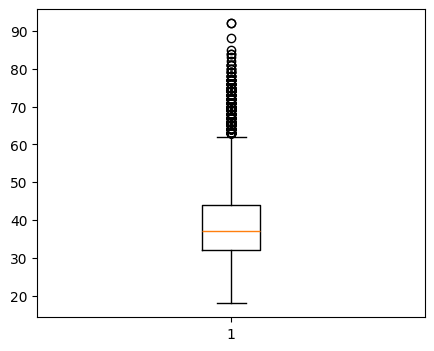

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df['age']);

In [ ]:
age = df['age'].to_list()

In [ ]:
Q1 = np.percentile(age, 25, interpolation= 'midpoint')
Q2 = np.percentile(age, 50, interpolation= 'midpoint')
Q3 = np.percentile(age, 75, interpolation= 'midpoint')

In [ ]:
IQR = Q3 - Q1

In [ ]:
print("old age outlier Are")
print("Minimum:", Q1 - 1.5 * IQR)
print("Maximum:", Q3 + 1.5 * IQR)

old age outlier Are
Minimum: 14.0
Maximum: 62.0


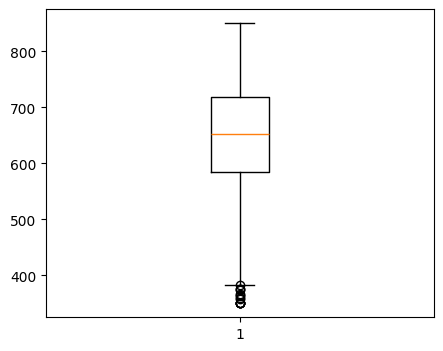

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df['credit_score']);

In [ ]:
age = df['credit_score'].to_list()

In [ ]:
credit = df['credit_score'].to_list()
Q1 = np.percentile(age, 25, interpolation= 'midpoint')
Q3 = np.percentile(age, 75, interpolation= 'midpoint')
IQR = Q3 - Q1
print("CreditScore outliers: Min", Q1 - 1.5 * IQR, "Max:", Q3 + 1.5 * IQR)

CreditScore outliers: Min 383.0 Max: 919.0


In [ ]:
outliers_credit = []
for i in credit:
  if i > (Q3 - 1.5 * IQR) or i < (Q1 + 1.5 * IQR):
    outliers_credit.append(i)
outliers_credit

[619,
 608,
 502,
 699,
 850,
 645,
 822,
 376,
 501,
 684,
 528,
 497,
 476,
 549,
 635,
 616,
 653,
 549,
 587,
 726,
 732,
 636,
 510,
 669,
 846,
 577,
 756,
 571,
 574,
 411,
 591,
 533,
 553,
 520,
 722,
 475,
 490,
 804,
 850,
 582,
 472,
 465,
 556,
 834,
 660,
 776,
 829,
 637,
 550,
 776,
 698,
 585,
 788,
 655,
 601,
 619,
 656,
 725,
 511,
 614,
 742,
 687,
 555,
 684,
 603,
 751,
 581,
 735,
 661,
 675,
 738,
 813,
 657,
 604,
 519,
 735,
 664,
 678,
 757,
 416,
 665,
 777,
 543,
 506,
 493,
 652,
 750,
 729,
 646,
 635,
 647,
 808,
 524,
 769,
 730,
 515,
 773,
 814,
 710,
 413,
 665,
 623,
 738,
 528,
 670,
 622,
 582,
 785,
 605,
 479,
 685,
 538,
 562,
 675,
 721,
 628,
 668,
 506,
 524,
 699,
 828,
 674,
 656,
 684,
 625,
 432,
 549,
 625,
 828,
 770,
 758,
 795,
 687,
 686,
 789,
 589,
 461,
 637,
 584,
 579,
 756,
 663,
 682,
 793,
 691,
 485,
 635,
 650,
 735,
 416,
 754,
 535,
 716,
 539,
 614,
 706,
 758,
 586,
 646,
 631,
 717,
 684,
 800,
 721,
 683,
 660,
 704

In [ ]:
balance = df['balance'].to_list()
Q1 = np.percentile(age, 25, interpolation= 'midpoint')
Q3 = np.percentile(age, 75, interpolation= 'midpoint')
IQR = Q3 - Q1
print("Balance outliers: Min", Q1 - 1.5 * IQR, "Max:", Q3 + 1.5 * IQR)

Balance outliers: Min 383.0 Max: 919.0


In [ ]:
outliers_balance = []
for i in balance:
  if i > (Q3 - 1.5 * IQR) or i < (Q1 + 1.5 * IQR):
    outliers_credit.append(i)
outliers_credit

[619,
 608,
 502,
 699,
 850,
 645,
 822,
 376,
 501,
 684,
 528,
 497,
 476,
 549,
 635,
 616,
 653,
 549,
 587,
 726,
 732,
 636,
 510,
 669,
 846,
 577,
 756,
 571,
 574,
 411,
 591,
 533,
 553,
 520,
 722,
 475,
 490,
 804,
 850,
 582,
 472,
 465,
 556,
 834,
 660,
 776,
 829,
 637,
 550,
 776,
 698,
 585,
 788,
 655,
 601,
 619,
 656,
 725,
 511,
 614,
 742,
 687,
 555,
 684,
 603,
 751,
 581,
 735,
 661,
 675,
 738,
 813,
 657,
 604,
 519,
 735,
 664,
 678,
 757,
 416,
 665,
 777,
 543,
 506,
 493,
 652,
 750,
 729,
 646,
 635,
 647,
 808,
 524,
 769,
 730,
 515,
 773,
 814,
 710,
 413,
 665,
 623,
 738,
 528,
 670,
 622,
 582,
 785,
 605,
 479,
 685,
 538,
 562,
 675,
 721,
 628,
 668,
 506,
 524,
 699,
 828,
 674,
 656,
 684,
 625,
 432,
 549,
 625,
 828,
 770,
 758,
 795,
 687,
 686,
 789,
 589,
 461,
 637,
 584,
 579,
 756,
 663,
 682,
 793,
 691,
 485,
 635,
 650,
 735,
 416,
 754,
 535,
 716,
 539,
 614,
 706,
 758,
 586,
 646,
 631,
 717,
 684,
 800,
 721,
 683,
 660,
 704

In [ ]:
df[df['balance'].isin(outliers_balance)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


**Estimated Salary**

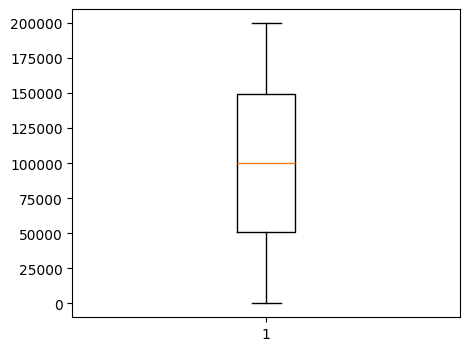

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df['estimated_salary']);

In [ ]:
salary = df['estimated_salary'].to_list()
Q1 = np.percentile(age, 25, interpolation= 'midpoint')
Q3 = np.percentile(age, 75, interpolation= 'midpoint')
IQR = Q3 - Q1
print("estimated_salary outliers: Min", Q1 - 1.5 * IQR, "Max:", Q3 + 1.5 * IQR)

estimated_salary outliers: Min 383.0 Max: 919.0


In [ ]:
outliers_salary = []
for i in salary:
  if i > (Q3 - 1.5 * IQR) or i < (Q1 + 1.5 * IQR):
    outliers_credit.append(i)
outliers_credit

[619,
 608,
 502,
 699,
 850,
 645,
 822,
 376,
 501,
 684,
 528,
 497,
 476,
 549,
 635,
 616,
 653,
 549,
 587,
 726,
 732,
 636,
 510,
 669,
 846,
 577,
 756,
 571,
 574,
 411,
 591,
 533,
 553,
 520,
 722,
 475,
 490,
 804,
 850,
 582,
 472,
 465,
 556,
 834,
 660,
 776,
 829,
 637,
 550,
 776,
 698,
 585,
 788,
 655,
 601,
 619,
 656,
 725,
 511,
 614,
 742,
 687,
 555,
 684,
 603,
 751,
 581,
 735,
 661,
 675,
 738,
 813,
 657,
 604,
 519,
 735,
 664,
 678,
 757,
 416,
 665,
 777,
 543,
 506,
 493,
 652,
 750,
 729,
 646,
 635,
 647,
 808,
 524,
 769,
 730,
 515,
 773,
 814,
 710,
 413,
 665,
 623,
 738,
 528,
 670,
 622,
 582,
 785,
 605,
 479,
 685,
 538,
 562,
 675,
 721,
 628,
 668,
 506,
 524,
 699,
 828,
 674,
 656,
 684,
 625,
 432,
 549,
 625,
 828,
 770,
 758,
 795,
 687,
 686,
 789,
 589,
 461,
 637,
 584,
 579,
 756,
 663,
 682,
 793,
 691,
 485,
 635,
 650,
 735,
 416,
 754,
 535,
 716,
 539,
 614,
 706,
 758,
 586,
 646,
 631,
 717,
 684,
 800,
 721,
 683,
 660,
 704

In [ ]:
df[df['estimated_salary'].isin(outliers_salary)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


**Visualisations**

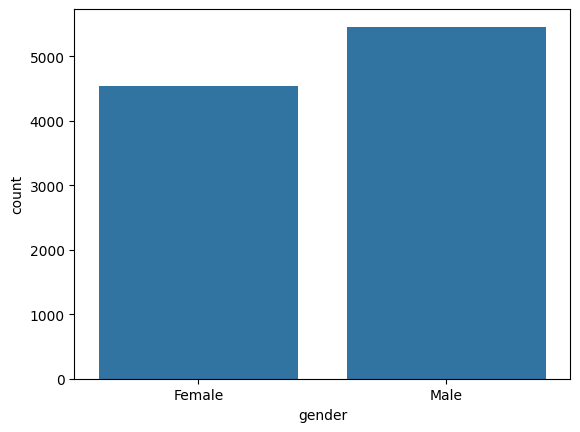

In [ ]:
sns.countplot(data = df, x= 'gender');
plt.show()

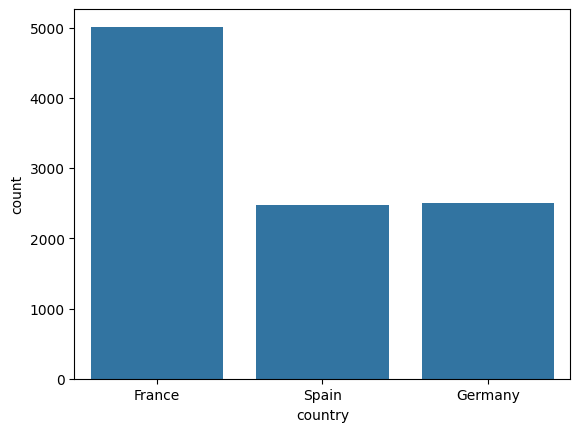

In [ ]:
sns.countplot(data = df, x= 'country');
plt.show()

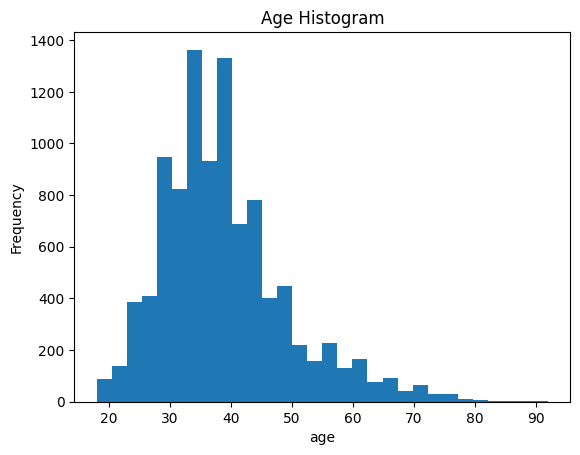

In [ ]:
#Histogram of age

plt.hist(df['age'], bins=30)
plt.title('Age Histogram')
plt.xlabel('age')
plt.ylabel('Frequency')
plt.show()

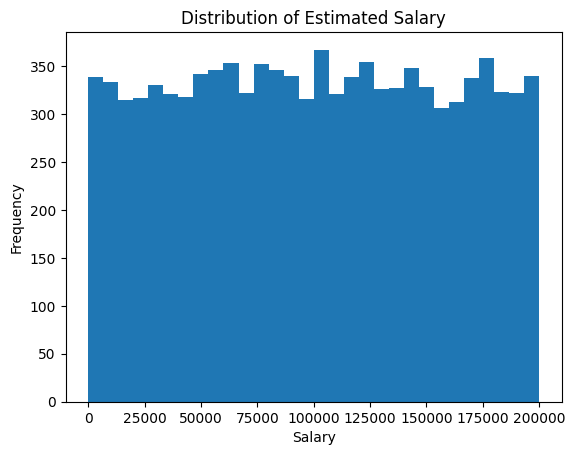

In [ ]:
plt.hist(df['estimated_salary'], bins=30)
plt.title('Distribution of Estimated Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

**Comparing the imp with the target**

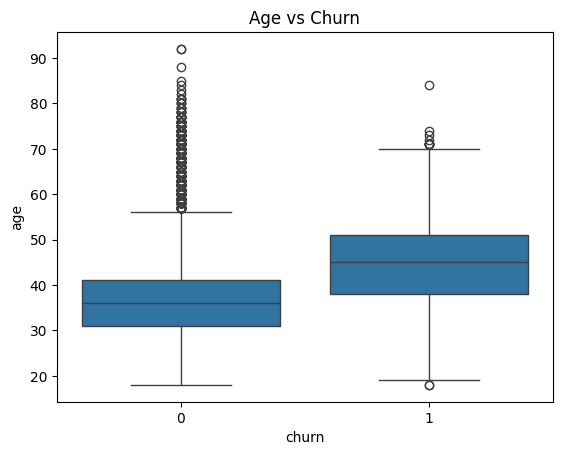

In [ ]:
sns.boxplot(data = df, x= 'churn', y= 'age');
plt.title('Age vs Churn');
plt.show()


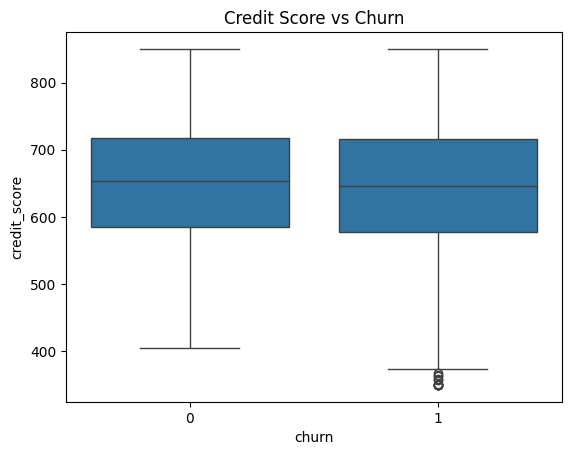

In [ ]:
sns.boxplot(data = df, x= 'churn', y= 'credit_score');
plt.title('Credit Score vs Churn');
plt.show()

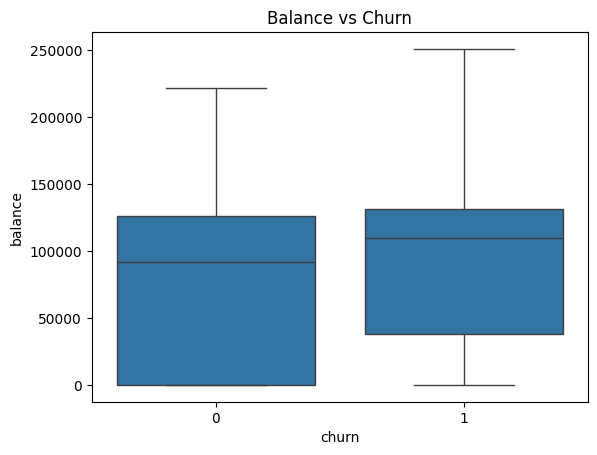

In [ ]:
sns.boxplot(data = df, x= 'churn', y= 'balance');
plt.title('Balance vs Churn');
plt.show()

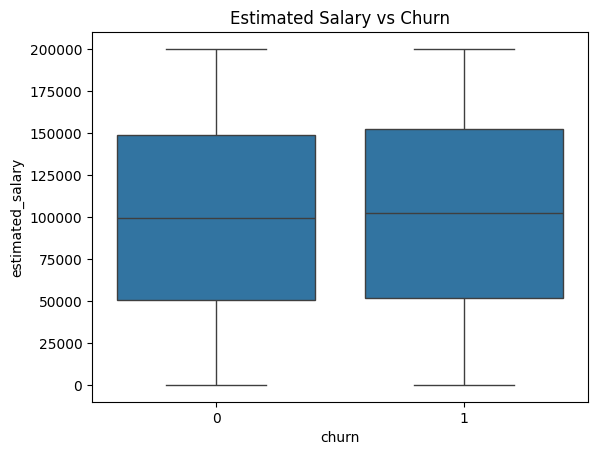

In [ ]:
sns.boxplot(data = df, x= 'churn', y= 'estimated_salary');
plt.title('Estimated Salary vs Churn');
plt.show()

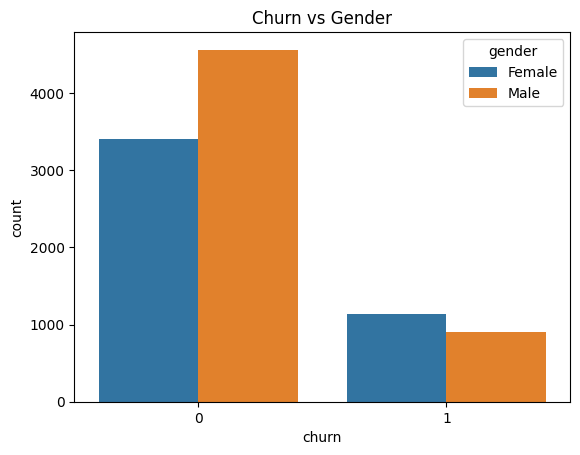

In [ ]:
sns.countplot(data = df, x= 'churn', hue= 'gender');
plt.title('Churn vs Gender');
plt.show()

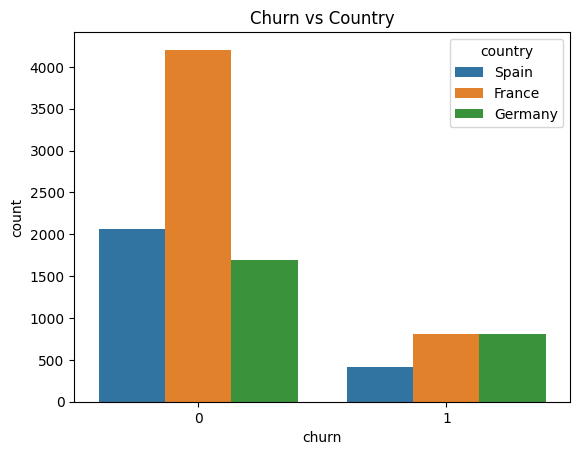

In [ ]:
sns.countplot(data = df, x= 'churn', hue= 'country');
plt.title('Churn vs Country');
plt.show()

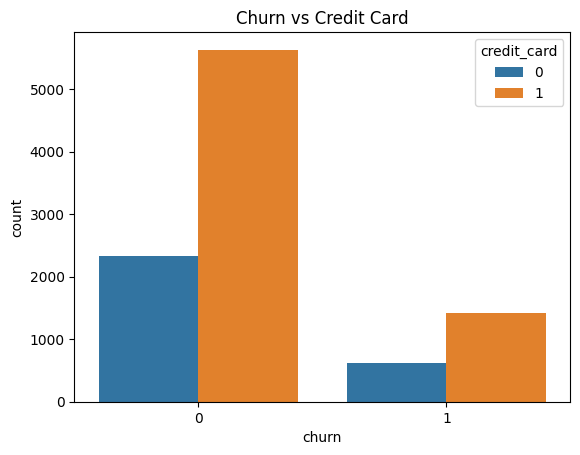

In [ ]:
sns.countplot(data = df, x= 'churn', hue= 'credit_card');
plt.title('Churn vs Credit Card');
plt.show()

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.drop(['customer_id'], axis=1, inplace=True)

In [ ]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
font_size = 15

plt.rcParams['axes.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size + 2
plt.rcParams['xtick.labelsize'] = font_size - 2
plt.rcParams['ytick.labelsize'] = font_size - 2
plt.rcParams['legend.fontsize'] = font_size - 2

In [ ]:
colors = ['green', 'pink', 'red', 'cyan']

(0.0, 9000.0)

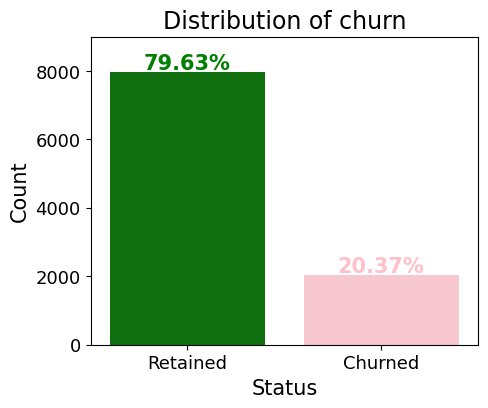

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.countplot(x='churn', data=df, palette=colors, ax=ax)

for index, value in enumerate(df['churn'].value_counts()):
    label = '{}%'.format(round((value / df['churn'].shape[0]) * 100, 2))
    ax.annotate(
        label,
        xy=(index, value + 250),
        ha='center',
        va='center',
        color=colors[index],
        fontweight='bold',
        size=font_size
    )

ax.set_xticklabels(['Retained', 'Churned'])
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_title('Distribution of churn')
ax.set_ylim((0, 9000))

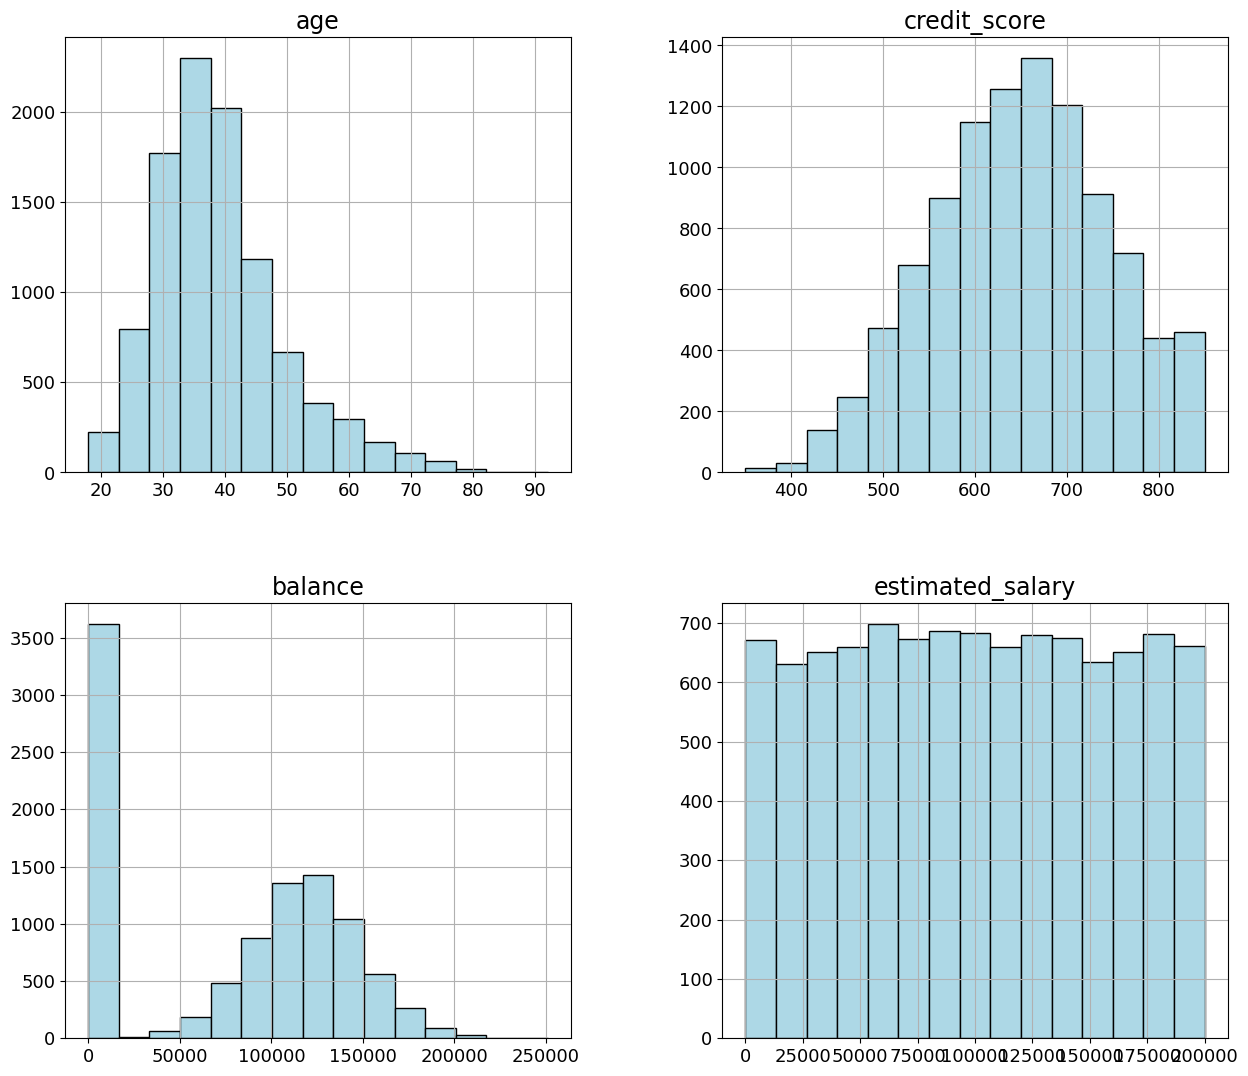

In [ ]:
df[mulcols].hist(
    figsize=(15, 13),
    bins=15,
    layout=(2, 2),
    color='lightblue',
    edgecolor='black',
    linewidth=1.0
);

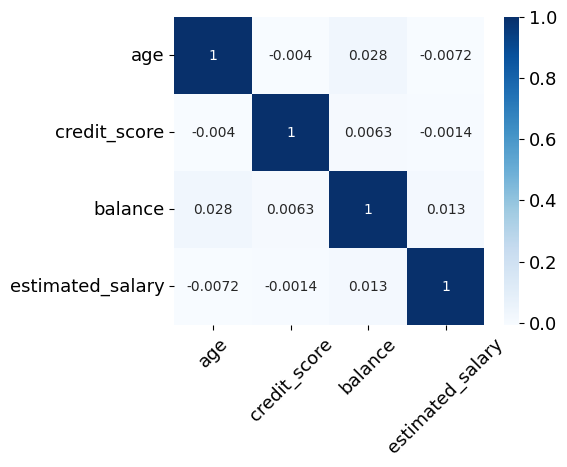

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    df[mulcols].corr(),
    annot=True,
    annot_kws={"fontsize": 10},
    cmap='Blues',
    ax=ax
)

ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=360)

In [ ]:
def plot_continuous(df, feature):

    df_func = df.copy()
    df_func['churn'] = df_func['churn'].astype('category')

    df_churned = df_func[df_func['churn'] == 1]
    df_retained = df_func[df_func['churn'] == 0]

    fig, (ax1, ax2) = plt.subplots(
        2,
        figsize=(9, 7),
        sharex=True,
        gridspec_kw={"height_ratios": (.7, .3)}
    )

    colors = ['#1f77b4', '#ff7f0e']

    for sub_df, color, label in zip(
        [df_retained, df_churned],
        colors,
        ['Retained', 'Churned']
    ):
        sns.histplot(
            data=sub_df,
            x=feature,
            bins=15,
            color=color,
            alpha=0.6,
            edgecolor='firebrick',
            label=label,
            kde=False,
            ax=ax1
        )

    ax1.legend()

    sns.boxplot(
        x=feature,
        y='churn',
        data=df_func,
        palette=colors,
        ax=ax2
    )

    ax2.set_ylabel('')
    ax2.set_yticklabels(['Retained', 'Churned'])

    plt.tight_layout()
    plt.show()

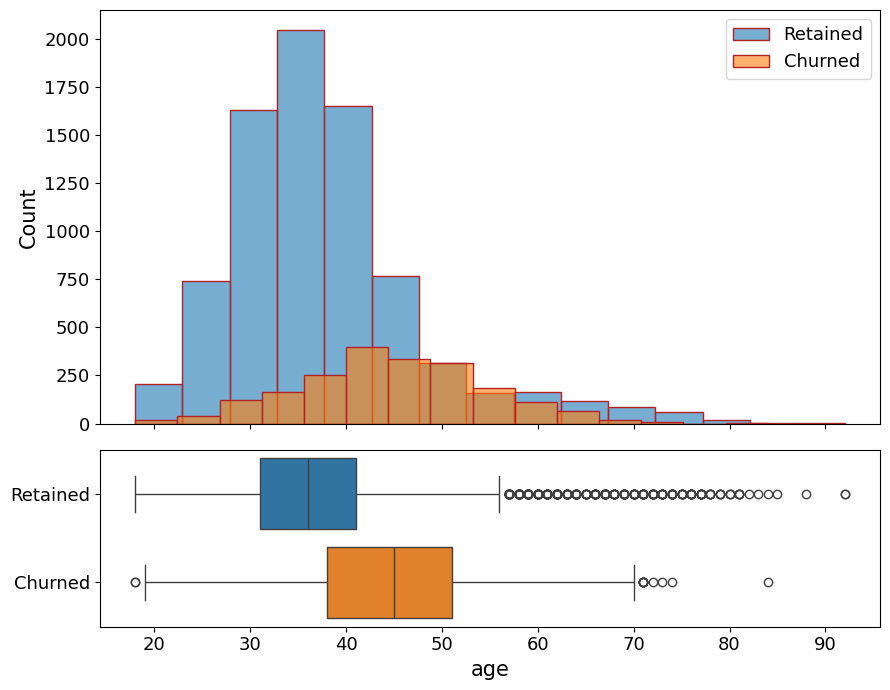

In [ ]:
plot_continuous(df, 'age')

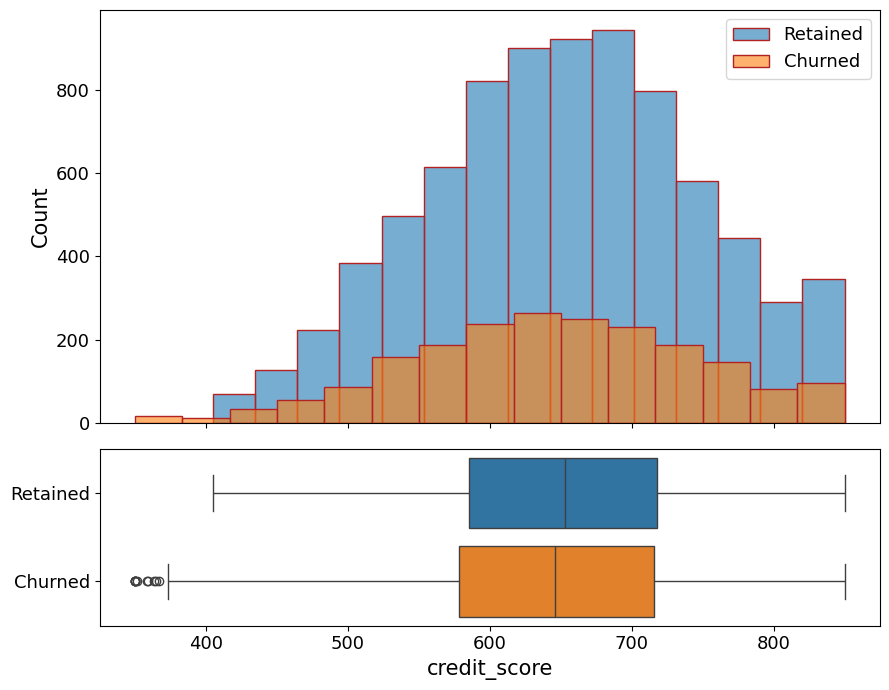

In [ ]:
plot_continuous(df, 'credit_score')

In [ ]:
categorical = [
    'country',
    'gender',
    'tenure',
    'products_number',
    'credit_card',
    'active_member'
]

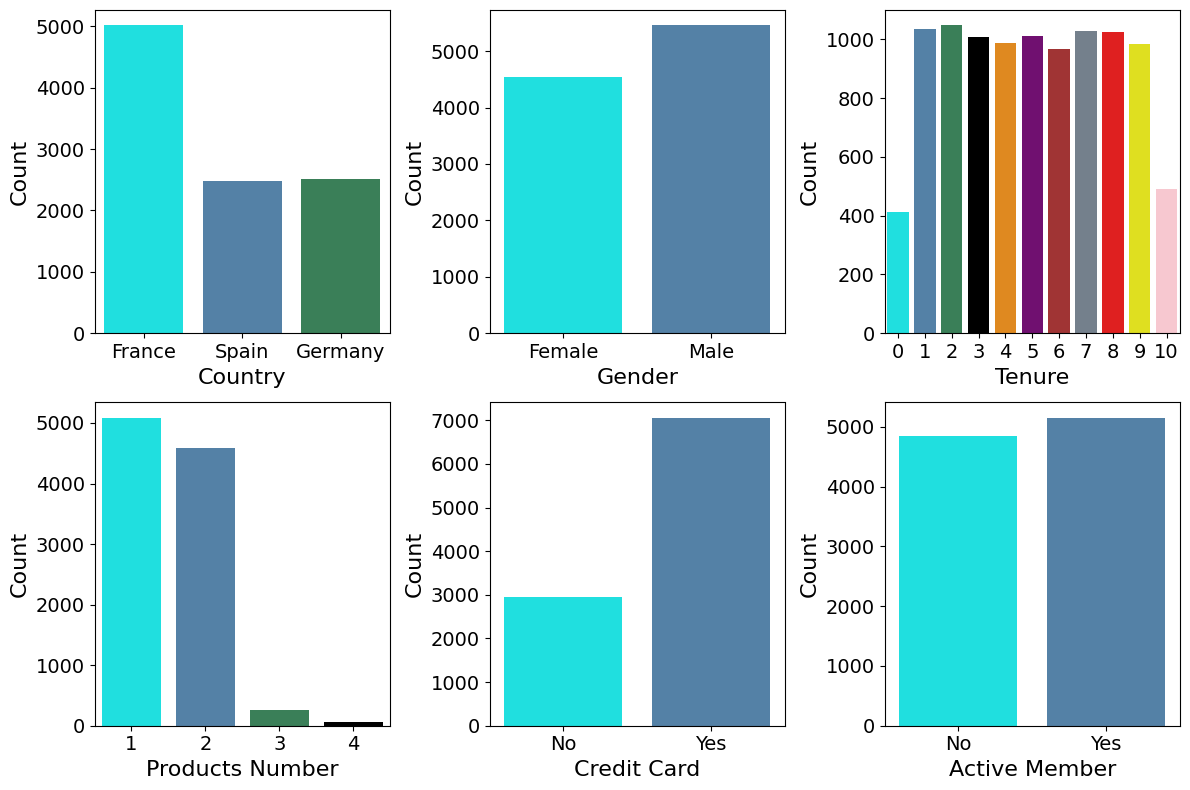

In [ ]:
font_size = 16

plt.rcParams['axes.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size + 2
plt.rcParams['xtick.labelsize'] = font_size - 2
plt.rcParams['ytick.labelsize'] = font_size - 2
plt.rcParams['legend.fontsize'] = font_size - 2

colors_cat = [
    'cyan',
    'steelblue',
    'seagreen',
    'black',
    'darkorange',
    'purple',
    'firebrick',
    'slategrey',
    'red',
    'yellow',
    'pink'
]

categorical = [
    'country',
    'gender',
    'tenure',
    'products_number',
    'credit_card',
    'active_member'
]

df_cat = df[categorical]

fig, ax = plt.subplots(2, 3, figsize=(12, 8))

for index, column in enumerate(df_cat.columns):

    plt.subplot(2, 3, index + 1)

    sns.countplot(
        x=column,
        data=df,
        palette=colors_cat
    )

    plt.ylabel('Count')
    plt.xlabel(column.replace('_', ' ').title())

    if column in ['credit_card', 'active_member']:
        plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [ ]:
features_drop = ['tenure', 'credit_card', 'estimated_salary']

In [ ]:
df = df.drop(features_drop, axis=1)

In [ ]:
df.head()

,credit_score,country,gender,age,balance,products_number,active_member,churn
0,619,France,Female,42,0.00,1,1,1
1,608,Spain,Female,41,83807.86,1,1,0
2,502,France,Female,42,159660.80,3,0,1
3,699,France,Female,39,0.00,2,0,0
4,850,Spain,Female,43,125510.82,1,1,0


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('churn', axis=1), df['churn'], test_size=0.2, random_state=43, stratify=df['churn'])

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 7), (2000, 7), (8000,), (2000,))

In [ ]:
y_train.value_counts()

,count
churn,
0,6370
1,1630


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,5457
Female,4543


In [ ]:
le = LabelEncoder()

In [ ]:
X_train['gender'].value_counts()

,count
gender,
Male,4388
Female,3612


In [ ]:
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender'])

In [ ]:
X_train['gender'].value_counts()

,count
gender,
1,4388
0,3612


In [ ]:
def country_conversion(df):
    df = df.copy()

    df['country'] = df['country'].map({
        'France': 0,
        'Spain': 1,
        'Germany': 2
    })

    return df

X_train = country_conversion(X_train)
X_test = country_conversion(X_test)

In [ ]:
X_train = Country_conversion(X_train)


In [ ]:
X_train['country'].value_counts()

,count
country,


In [ ]:
X_train['gender'] = X_train['gender'].map({
    'Female': 0,
    'Male': 1
})

X_test['gender'] = X_test['gender'].map({
    'Female': 0,
    'Male': 1
})

In [ ]:
print(X_train.dtypes)

credit_score       float64
country            float64
gender             float64
age                float64
balance            float64
products_number      int64
active_member        int64
dtype: object


In [ ]:
X_train['country'].value_counts()

,count
country,
France,4017
Germany,2010
Spain,1973


In [ ]:
X_test['country'].value_counts()

,count
country,
France,997
Spain,504
Germany,499


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scl_columns = ['credit_score', 'age', 'balance']

X_train[scl_columns] = scaler.fit_transform(X_train[scl_columns])
X_test[scl_columns] = scaler.transform(X_test[scl_columns])

X_test.describe()

,credit_score,gender,age,balance,products_number,active_member
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-0.033807,0.534500,0.011624,0.015568,1.530500,0.520500
std,1.021885,0.498933,1.016906,1.005583,0.590122,0.499705
min,-3.130116,0.000000,-1.999353,-1.224068,1.000000,0.000000
25%,-0.750150,0.000000,-0.659913,-1.224068,1.000000,0.000000
50%,-0.001864,1.000000,-0.181542,0.345463,1.000000,1.000000
75%,0.684065,1.000000,0.488178,0.824440,2.000000,1.000000
max,2.066315,1.000000,4.410824,2.188494,4.000000,1.000000


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
X_train.isnull().sum()

,0
credit_score,0
country,8000
gender,8000
age,0
balance,0
products_number,0
active_member,0


In [ ]:
X_train.isna().sum()

,0
credit_score,0
country,8000
gender,8000
age,0
balance,0
products_number,0
active_member,0


In [ ]:
print(X_train.shape)
print(X_train.columns)
print(X_train.dtypes)

(8000, 7)
Index(['credit_score', 'country', 'gender', 'age', 'balance',
       'products_number', 'active_member'],
      dtype='object')
credit_score       float64
country            float64
gender             float64
age                float64
balance            float64
products_number      int64
active_member        int64
dtype: object


In [ ]:
print(X_train.isnull().sum())

credit_score          0
country            8000
gender             8000
age                   0
balance               0
products_number       0
active_member         0
dtype: int64


In [ ]:
print(df['country'].unique())
print(df['gender'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [ ]:
print(X_train['country'].unique())
print(X_train['gender'].unique())

[nan]
[nan]


In [ ]:
df['country'] = df['country'].map({
    'France': 0,
    'Spain': 1,
    'Germany': 2
})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_gender = LabelEncoder()

X_train['country'] = le_country.fit_transform(X_train['country'])
X_test['country'] = le_country.transform(X_test['country'])

X_train['gender'] = le_gender.fit_transform(X_train['gender'])
X_test['gender'] = le_gender.transform(X_test['gender'])

ValueError: y contains previously unseen labels: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

In [ ]:
print("X_train country:", X_train['country'].unique())
print("X_test country:", X_test['country'].unique())

print("X_train gender:", X_train['gender'].unique())
print("X_test gender:", X_test['gender'].unique())

X_train country: [0]
X_test country: [0 1 2]
X_train gender: [nan]
X_test gender: [nan]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train['country'].unique())
print(X_test['country'].unique())

[0 2 1]
[0 2 1]


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
print(X_train.isnull().sum())
print(X_train['gender'].unique())
print(X_test['gender'].unique())

credit_score       0
country            0
gender             0
age                0
balance            0
products_number    0
active_member      0
dtype: int64
[1 0]
[1 0]


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(12740, 7)
churn
1    6370
0    6370
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC

In [ ]:
scoring_metric = 'accuracy'

In [ ]:
scoring_metric = 'accuracy'

clf_list = [
    ('Logistic Regression', LogisticRegression(random_state=43))
]

cv_base_mean, cv_std = [], []

for clf in clf_list:

    cv = cross_val_score(
        estimator=clf[1],
        X=X_train,
        y=y_train,
        scoring=scoring_metric,
        cv=5,
        n_jobs=-1
    )

    cv_base_mean.append(cv.mean())
    cv_std.append(cv.std())

print('BaseLine Models (Recall):')

for i in range(len(clf_list)):
    print(
        '    {}: {}'.format(
            clf_list[i][0],
            np.round(cv_base_mean[i], 2)
        )
    )

BaseLine Models (Recall):
    Logistic Regression: 0.81


In [ ]:
clf_list = [
    ('Logistic Regression', LogisticRegression(random_state=43)),
    ('Decision Tree', DecisionTreeClassifier(random_state=43)),
    ('Random Forest', RandomForestClassifier(random_state=43))
]

In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score, auc, roc_auc_score, roc_curve
from sklearn.metrics import classification_report

In [ ]:
lr = LogisticRegression(random_state=43)

param_grid = {
    'max_iter': [100],
    'penalty': ['l1', 'l2'],
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

lr_clf = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring=scoring_metric,
    cv=5,
    verbose=False,
    n_jobs=-1
)

best_lr_clf = lr_clf.fit(X_train, y_train)

In [ ]:
best_lr_clf.best_estimator_

LogisticRegression(C=10, penalty='l1', random_state=43, solver='liblinear')

In [ ]:
lr_best = LogisticRegression(C=10, penalty='l1', random_state=43, solver='liblinear')

In [ ]:
lr_best = LogisticRegression(
    C=10,
    penalty='l1',
    random_state=43,
    solver='liblinear'
)

In [ ]:
best_lr_clf = lr_clf.fit(X_train, y_train)

In [ ]:
lr_best = best_lr_clf.best_estimator_

y_train_lr_pred = lr_best.predict(X_train)
y_test_lr_pred = lr_best.predict(X_test)

In [ ]:
lr_best = LogisticRegression(
    C=10,
    penalty='l1',
    random_state=43,
    solver='liblinear'
)

lr_best.fit(X_train, y_train)

y_train_lr_pred = lr_best.predict(X_train)
y_test_lr_pred = lr_best.predict(X_test)

In [ ]:
print(best_lr_clf.best_params_)
print(best_lr_clf.best_score_)

{'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
0.8127500000000001


In [ ]:
lr_best = best_lr_clf.best_estimator_

In [ ]:
lr_best = best_lr_clf.best_estimator_

In [ ]:
best_lr_clf = lr_clf.fit(X_train, y_train)

In [ ]:
lr_best.fit(X_train, y_train)

LogisticRegression(C=10, penalty='l1', random_state=43, solver='liblinear')

In [ ]:
y_train_lr_pred = lr_best.predict(X_train)


In [ ]:
print(classification_report(y_train, y_train_lr_pred))

              precision    recall  f1-score   support

           0       0.77      0.76      0.76      6370
           1       0.76      0.78      0.77      6370

    accuracy                           0.77     12740
   macro avg       0.77      0.77      0.77     12740
weighted avg       0.77      0.77      0.77     12740



In [ ]:
!pip install xgboost lightgbm

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install xgboost

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
# Find the best parameter using GridSearchCV

rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 150],
    'criterion': ['entropy', 'gini'],
    'bootstrap': [True, False],
    'max_depth': [4, 5, 6],
    'max_features': ['auto', 'sqrt'],
    'min_samples_leaf': [2, 3, 5],
    'min_samples_split': [2, 3, 5]
}

rf_clf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=False,
    n_jobs=-1
)

best_rf_clf = rf_clf.fit(X_train, y_train)